# 02. Clean modelling pipeline

Этот notebook собирает чистовой research-pipeline для моделирования цен опционов на фьючерс `MXI`.

Что здесь исправлено по сравнению с ранними черновиками:
- используется **правильный underlying**: `MXI` futures, а не `IMOEX` spot;
- признаки `moneyness`, `log_moneyness`, волатильность и режимы считаются по **фьючерсному underlying**;
- для волатильности `GARCH` используется **expanding one-step-ahead forecast** без look-ahead bias;
- основная pricing-модель строится для **американских опционов на фьючерс** через `CRR binomial tree`;
- `Black-76` можно держать как дополнительный европейский benchmark, но не как основную модель.

Notebook специально написан как чистовой шаблон: его нужно запускать после проверки данных, но в текущем шаге он **не исполняется автоматически**.


## Архивная пометка

Старый notebook `practice/01_check_options_dataset.ipynb` теперь следует считать архивным sanity-check. Он был построен на раннем merged dataset со старым `IMOEX` underlying и больше не используется для финальных выводов. Все актуальные расчёты и сравнения в этой версии notebook строятся только на clean dataset с `MXI` futures underlying.


## Замечание по quality filter

В этой clean-версии intentionally **не используются** старые жёсткие теоретические ограничения вида `moneyness in [0.7, 1.8]` и `market_price <= strike + underlying`. Для американских опционов на фьючерс такие границы слишком грубые. Вместо этого ниже мы оставляем мягкий operational filter и отдельный diagnostic block по экстремальным наблюдениям.


In [1]:
# pip install arch

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
from arch import arch_model
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf


## 1. Загрузка clean dataset

На вход берётся уже пересобранный датасет `MM`-опционов с привязкой к соответствующему `MXI` futures contract по дате и серии underlying.


In [3]:
project_root = Path('/Users/maria/Desktop/Code/HSE/COURSEBOOK')
input_path = project_root / 'clear/mm_options_with_mxi_underlying_2024_2026.parquet'
results_dir = project_root / 'clear/results_models'
results_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(input_path)
df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'], errors='coerce').dt.normalize()
df['expiry_date'] = pd.to_datetime(df['expiry_date'], errors='coerce').dt.normalize()

numeric_cols = [
    'strike', 'SETTLEPRICE', 'market_price', 'underlying_price', 'UNDERLYING_SETTLEPRICE',
    'UNDERLYING_OPEN', 'UNDERLYING_HIGH', 'UNDERLYING_LOW', 'UNDERLYING_CLOSE',
    'UNDERLYING_VALUE', 'UNDERLYING_VOLUME', 'UNDERLYING_OPENPOSITION', 'UNDERLYING_NUMTRADES',
    'DTE_DAYS'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fix core modelling aliases.
df['market_price'] = df['SETTLEPRICE']
df['F'] = df['underlying_price']
df['K'] = df['strike']
df['DTE_DAYS'] = (df['expiry_date'] - df['TRADEDATE']).dt.days
df['T'] = df['DTE_DAYS'] / 365.0
df['r'] = 0.16
df['option_type_norm'] = df['option_type'].astype(str).str.upper().map({'C': 'call', 'P': 'put'})

df.shape


(19574, 39)

## 2. Подготовка modelling sample

Здесь мы оставляем только те наблюдения, которые пригодны для расчёта model price. Важно: фильтры уже основаны на **фьючерсной цене** и не используют старый `IMOEX` spot-based moneyness.


In [4]:
df['moneyness'] = df['F'] / df['K']
df['log_moneyness'] = np.log(df['moneyness'])
df['year'] = df['TRADEDATE'].dt.year
df['month'] = df['TRADEDATE'].dt.month

filter_checks = {
    'bad_trade_date': int(df['TRADEDATE'].isna().sum()),
    'bad_expiry_date': int(df['expiry_date'].isna().sum()),
    'bad_nonpositive_market_price': int((df['market_price'] <= 0).sum()),
    'bad_nonpositive_futures_price': int((df['F'] <= 0).sum()),
    'bad_nonpositive_strike': int((df['K'] <= 0).sum()),
    'bad_nonpositive_dte': int((df['DTE_DAYS'] <= 0).sum()),
    'bad_option_type': int((~df['option_type_norm'].isin(['call', 'put'])).sum()),
    'bad_missing_underlying_secid': int(df['UNDERLYING_SECID'].isna().sum()),
}
pd.Series(filter_checks).sort_values(ascending=False)


bad_nonpositive_dte              9
bad_nonpositive_market_price     6
bad_trade_date                   0
bad_expiry_date                  0
bad_nonpositive_futures_price    0
bad_nonpositive_strike           0
bad_option_type                  0
bad_missing_underlying_secid     0
dtype: int64

In [5]:
modelling_mask = (
    df['TRADEDATE'].notna()
    & df['expiry_date'].notna()
    & (df['market_price'] > 0)
    & (df['F'] > 0)
    & (df['K'] > 0)
    & (df['DTE_DAYS'] > 0)
    & df['option_type_norm'].isin(['call', 'put'])
    & df['UNDERLYING_SECID'].notna()
)

modelling_df = (
    df.loc[modelling_mask]
    .copy()
    .sort_values(['TRADEDATE', 'UNDERLYING_SECID', 'expiry_date', 'K', 'option_type_norm', 'SECID'])
    .reset_index(drop=True)
)

print('Original rows:', len(df))
print('Modelling rows:', len(modelling_df))
print('Share kept:', round(len(modelling_df) / len(df), 4))


Original rows: 19574
Modelling rows: 19565
Share kept: 0.9995


## 2a. Soft diagnostics вместо жёстких теоретических отсечек

Мы не выбрасываем наблюдения по старым ad hoc ограничениям, но отдельно смотрим, сколько есть потенциально экстремальных значений по `moneyness`, `DTE` и цене опциона. Это позволяет сохранить выборку максимально полной и при этом понимать, где находятся хвосты.


In [6]:
soft_diagnostics = {
    'share_moneyness_lt_0_7': float((modelling_df['moneyness'] < 0.7).mean()),
    'share_moneyness_gt_1_8': float((modelling_df['moneyness'] > 1.8).mean()),
    'share_dte_gt_365': float((modelling_df['DTE_DAYS'] > 365).mean()),
    'share_dte_gt_730': float((modelling_df['DTE_DAYS'] > 730).mean()),
    'share_market_price_gt_strike_plus_f': float((modelling_df['market_price'] > (modelling_df['K'] + modelling_df['F'])).mean()),
}
pd.Series(soft_diagnostics)


share_moneyness_lt_0_7                 0.000000
share_moneyness_gt_1_8                 0.035472
share_dte_gt_365                       0.604753
share_dte_gt_730                       0.247074
share_market_price_gt_strike_plus_f    0.000000
dtype: float64

## 3. Волатильность и рыночные режимы

Ключевая идея: историческая волатильность и режимы считаются по **доходностям соответствующего MXI futures contract**. Это исправляет старую проблему, когда признаки строились по индексу `IMOEX`, а не по реальному базовому активу опциона.


In [7]:
underlying_daily = (
    modelling_df[
        ['TRADEDATE', 'UNDERLYING_SECID', 'UNDERLYING_SHORTNAME', 'F']
    ]
    .drop_duplicates()
    .sort_values(['UNDERLYING_SECID', 'TRADEDATE'])
    .reset_index(drop=True)
)

underlying_daily['ret_1d'] = underlying_daily.groupby('UNDERLYING_SECID')['F'].transform(
    lambda s: np.log(s).diff()
)
underlying_daily['ret_21d'] = underlying_daily.groupby('UNDERLYING_SECID')['F'].transform(
    lambda s: np.log(s / s.shift(21))
)
underlying_daily['hv_21d'] = underlying_daily.groupby('UNDERLYING_SECID')['ret_1d'].transform(
    lambda s: s.rolling(21).std() * np.sqrt(252)
)
underlying_daily['hv_63d'] = underlying_daily.groupby('UNDERLYING_SECID')['ret_1d'].transform(
    lambda s: s.rolling(63).std() * np.sqrt(252)
)

vol_q = underlying_daily['hv_21d'].dropna().quantile([1/3, 2/3]).to_dict()
vol_q1 = vol_q.get(1/3, np.nan)
vol_q2 = vol_q.get(2/3, np.nan)

underlying_daily['vol_regime'] = pd.cut(
    underlying_daily['hv_21d'],
    bins=[-np.inf, vol_q1, vol_q2, np.inf],
    labels=['low_vol', 'mid_vol', 'high_vol'],
)
underlying_daily['trend_regime'] = np.select(
    [underlying_daily['ret_21d'] > 0, underlying_daily['ret_21d'] <= 0],
    ['up', 'down'],
    default=pd.NA,
)
underlying_daily['regime_label'] = np.where(
    underlying_daily['vol_regime'].isna(),
    pd.NA,
    underlying_daily['vol_regime'].astype(str) + '_' + underlying_daily['trend_regime'],
)

modelling_df = modelling_df.merge(
    underlying_daily[
        ['TRADEDATE', 'UNDERLYING_SECID', 'ret_1d', 'ret_21d', 'hv_21d', 'hv_63d', 'vol_regime', 'trend_regime', 'regime_label']
    ],
    on=['TRADEDATE', 'UNDERLYING_SECID'],
    how='left',
)

modelling_df[['TRADEDATE', 'UNDERLYING_SECID', 'F', 'hv_21d', 'hv_63d', 'vol_regime']].head()


,TRADEDATE,UNDERLYING_SECID,F,hv_21d,hv_63d,vol_regime
0,2024-01-03,MMH7,4575.45,NaN,NaN,NaN
1,2024-01-03,MMH7,4575.45,NaN,NaN,NaN
2,2024-01-03,MMM6,4080.25,NaN,NaN,NaN
3,2024-01-03,MMM6,4080.25,NaN,NaN,NaN
4,2024-01-03,MMM6,4080.25,NaN,NaN,NaN


## 4. GARCH without look-ahead bias

Здесь используется **expanding one-step-ahead forecast**. Для каждой даты модель `GARCH(1,1)` переоценивается только на прошлых наблюдениях внутри соответствующего `UNDERLYING_SECID`. Это медленнее, но методологически чище, чем брать `conditional_volatility` из модели, оценённой на всей выборке сразу.


In [8]:
def compute_expanding_garch_forecast(underlying_frame: pd.DataFrame, min_obs: int = 63, refit_every: int = 21) -> pd.DataFrame:
    rows = []

    for secid, part in underlying_frame.groupby('UNDERLYING_SECID', observed=False):
        part = part.sort_values('TRADEDATE').copy()
        returns = part['ret_1d'].to_numpy()
        forecasts = [np.nan] * len(part)
        fit = None
        params = None
        last_variance = np.nan

        for i in range(min_obs, len(part)):
            hist = returns[:i]
            hist = hist[np.isfinite(hist)]
            if len(hist) < min_obs:
                continue

            if fit is None or (i - min_obs) % refit_every == 0:
                try:
                    model = arch_model(
                        hist * 100.0,
                        mean='Zero',
                        vol='GARCH',
                        p=1,
                        q=1,
                        dist='normal',
                        rescale=False,
                    )
                    fit = model.fit(disp='off', update_freq=0)
                    params = fit.params
                    last_variance = np.nan
                except Exception:
                    fit = None
                    params = None
                    last_variance = np.nan

            if fit is None or params is None:
                continue

            try:
                if np.isfinite(last_variance) and np.isfinite(returns[i - 1]):
                    forecast_var = (
                        float(params['omega'])
                        + float(params['alpha[1]']) * float((returns[i - 1] * 100.0) ** 2)
                        + float(params['beta[1]']) * float(last_variance)
                    )
                else:
                    forecast_var = float(fit.forecast(horizon=1, reindex=False).variance.iloc[-1, 0])
                last_variance = forecast_var
                forecasts[i] = np.sqrt(forecast_var) / 100.0 * np.sqrt(252)
            except Exception:
                forecasts[i] = np.nan

        out = part[['TRADEDATE', 'UNDERLYING_SECID']].copy()
        out['garch_vol'] = forecasts
        rows.append(out)

    if not rows:
        return pd.DataFrame(columns=['TRADEDATE', 'UNDERLYING_SECID', 'garch_vol'])
    return pd.concat(rows, ignore_index=True)

garch_forecasts = compute_expanding_garch_forecast(underlying_daily, min_obs=63, refit_every=21)
modelling_df = modelling_df.merge(garch_forecasts, on=['TRADEDATE', 'UNDERLYING_SECID'], how='left')

print('garch non-null share:', round(float(modelling_df['garch_vol'].notna().mean()), 4))
modelling_df[['TRADEDATE', 'UNDERLYING_SECID', 'hv_21d', 'hv_63d', 'garch_vol']].head()


garch non-null share: 0.923


,TRADEDATE,UNDERLYING_SECID,hv_21d,hv_63d,garch_vol
0,2024-01-03,MMH7,NaN,NaN,NaN
1,2024-01-03,MMH7,NaN,NaN,NaN
2,2024-01-03,MMM6,NaN,NaN,NaN
3,2024-01-03,MMM6,NaN,NaN,NaN
4,2024-01-03,MMM6,NaN,NaN,NaN


## 5. Pricing models

Основная pricing-логика должна учитывать, что в данных лежат **американские опционы на фьючерс**. Поэтому здесь используется `CRR binomial tree` для американских опционов на futures. `Black-76` оставлен как дополнительный европейский benchmark, но не как основная модель.


In [9]:
def black76_price(F, K, T, r, sigma, option_type):
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    r = np.asarray(r, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    sqrt_T = np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    disc = np.exp(-r * T)

    call = disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
    put = disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return np.where(np.asarray(option_type) == 'call', call, put)


def american_futures_option_crr(F, K, T, r, sigma, option_type, steps=200):
    if not np.isfinite(F) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if F <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan
    if option_type not in {'call', 'put'}:
        return np.nan

    dt = T / steps
    if dt <= 0:
        return np.nan

    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    if not np.isfinite(u) or not np.isfinite(d) or u == d:
        return np.nan

    p = (1.0 - d) / (u - d)
    if p < 0 or p > 1:
        return np.nan

    disc = np.exp(-r * dt)
    j = np.arange(steps + 1)
    futures_at_maturity = F * (u ** j) * (d ** (steps - j))

    if option_type == 'call':
        values = np.maximum(futures_at_maturity - K, 0.0)
    else:
        values = np.maximum(K - futures_at_maturity, 0.0)

    for step in range(steps - 1, -1, -1):
        values = disc * (p * values[1: step + 2] + (1.0 - p) * values[0: step + 1])
        j = np.arange(step + 1)
        futures_now = F * (u ** j) * (d ** (step - j))
        if option_type == 'call':
            exercise = np.maximum(futures_now - K, 0.0)
        else:
            exercise = np.maximum(K - futures_now, 0.0)
        values = np.maximum(values, exercise)

    return float(values[0])


## 6. Расчёт модельных цен

Ниже готовится код для трёх volatility inputs:
- `hv_21d`
- `hv_63d`
- `garch_vol`

При желании можно считать и европейский benchmark `Black-76`, и основную американскую модель `CRR`. Для финального анализа лучше фокусироваться на `CRR`-ценах.


In [10]:
def add_model_block(frame: pd.DataFrame, sigma_col: str, model_prefix: str, use_american: bool = True, steps: int = 100) -> pd.DataFrame:
    out = frame.copy()
    valid_mask = (
        (out['market_price'] > 0)
        & (out['F'] > 0)
        & (out['K'] > 0)
        & (out['T'] > 0)
        & (out[sigma_col] > 0)
        & out['option_type_norm'].isin(['call', 'put'])
    )

    model_col = f'model_price_{model_prefix}'
    error_col = f'error_{model_prefix}'
    abs_col = f'abs_error_{model_prefix}'
    pct_col = f'pct_error_{model_prefix}'
    sq_col = f'squared_error_{model_prefix}'

    out[model_col] = np.nan

    if use_american:
        out.loc[valid_mask, model_col] = out.loc[valid_mask].apply(
            lambda row: american_futures_option_crr(
                F=float(row['F']),
                K=float(row['K']),
                T=float(row['T']),
                r=float(row['r']),
                sigma=float(row[sigma_col]),
                option_type=str(row['option_type_norm']),
                steps=steps,
            ),
            axis=1,
        )
    else:
        out.loc[valid_mask, model_col] = black76_price(
            F=out.loc[valid_mask, 'F'],
            K=out.loc[valid_mask, 'K'],
            T=out.loc[valid_mask, 'T'],
            r=out.loc[valid_mask, 'r'],
            sigma=out.loc[valid_mask, sigma_col],
            option_type=out.loc[valid_mask, 'option_type_norm'],
        )

    out[error_col] = out[model_col] - out['market_price']
    out[abs_col] = out[error_col].abs()
    out[pct_col] = out[error_col] / out['market_price']
    out[sq_col] = out[error_col] ** 2
    return out

pricing_df = modelling_df.copy()
pricing_df = add_model_block(pricing_df, sigma_col='hv_21d', model_prefix='crr_hv_21d', use_american=True, steps=100)
pricing_df = add_model_block(pricing_df, sigma_col='hv_63d', model_prefix='crr_hv_63d', use_american=True, steps=100)
pricing_df = add_model_block(pricing_df, sigma_col='garch_vol', model_prefix='crr_garch', use_american=True, steps=100)
pricing_df = add_model_block(pricing_df, sigma_col='hv_63d', model_prefix='black76_hv_63d', use_american=False)

display(pricing_df[[
    'SECID', 'TRADEDATE', 'market_price', 'F', 'K', 'hv_21d', 'hv_63d', 'garch_vol',
    'model_price_crr_hv_21d', 'model_price_crr_hv_63d', 'model_price_crr_garch', 'model_price_black76_hv_63d'
]].head())


,SECID,TRADEDATE,market_price,F,K,hv_21d,hv_63d,garch_vol,model_price_crr_hv_21d,model_price_crr_hv_63d,model_price_crr_garch,model_price_black76_hv_63d
0,MM3150BC7,2024-01-03,1513.80,4575.45,3150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MM3200BC7,2024-01-03,1470.10,4575.45,3200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MM2500BR6,2024-01-03,37.55,4080.25,2500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MM2550BR6,2024-01-03,40.45,4080.25,2550.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MM2600BF6,2024-01-03,1523.90,4080.25,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Метрики качества

Этот блок заменяет ранние comparison tables и считает ошибки уже на корректной выборке. Важно: сравнение моделей нужно делать **только на общем пересечении наблюдений**, где все сравниваемые модели имеют непустые model prices.


In [11]:
def calc_metrics(frame: pd.DataFrame, model_prefix: str) -> dict:
    model_col = f'model_price_{model_prefix}'
    err_col = f'error_{model_prefix}'
    abs_col = f'abs_error_{model_prefix}'
    sq_col = f'squared_error_{model_prefix}'
    pct_col = f'pct_error_{model_prefix}'

    sub = frame.loc[frame[model_col].notna()].copy()
    if sub.empty:
        return {
            'N': 0,
            'MAE': np.nan,
            'RMSE': np.nan,
            'mean_error': np.nan,
            'median_abs_error': np.nan,
            'mean_abs_pct_error': np.nan,
        }

    return {
        'N': int(len(sub)),
        'MAE': float(sub[abs_col].mean()),
        'RMSE': float(np.sqrt(sub[sq_col].mean())),
        'mean_error': float(sub[err_col].mean()),
        'median_abs_error': float(sub[abs_col].median()),
        'mean_abs_pct_error': float(sub[pct_col].abs().mean()),
    }


def calc_metrics_by_group(frame: pd.DataFrame, model_prefix: str, group_col: str) -> pd.DataFrame:
    model_col = f'model_price_{model_prefix}'
    err_col = f'error_{model_prefix}'
    abs_col = f'abs_error_{model_prefix}'
    sq_col = f'squared_error_{model_prefix}'

    sub = frame.loc[frame[model_col].notna()].copy()
    out = (
        sub.groupby(group_col, dropna=False, observed=False)
        .agg(
            N=(err_col, 'size'),
            MAE=(abs_col, 'mean'),
            mean_error=(err_col, 'mean'),
            median_abs_error=(abs_col, 'median'),
        )
        .reset_index()
    )
    rmse = (
        sub.groupby(group_col, dropna=False, observed=False)[sq_col]
        .apply(lambda s: float(np.sqrt(np.mean(s))))
        .reset_index(name='RMSE')
    )
    return out.merge(rmse, on=group_col, how='left')


def restrict_to_common_sample(frame: pd.DataFrame, model_prefixes: list[str]) -> pd.DataFrame:
    mask = np.ones(len(frame), dtype=bool)
    for prefix in model_prefixes:
        mask &= frame[f'model_price_{prefix}'].notna().to_numpy()
    return frame.loc[mask].copy()

# Example:
# compare_models = ['crr_hv_21d', 'crr_hv_63d', 'crr_garch']
# common_df = restrict_to_common_sample(pricing_df, compare_models)
# overall = pd.DataFrame([{'model': m, **calc_metrics(common_df, m)} for m in compare_models]).sort_values('MAE')
# overall


## 8. Срезы для error analysis

Здесь заранее подготавливаются те же аналитические корзины, что и в исследовательских notebook, но уже на корректной базе с `MXI` futures underlying.


In [12]:
analysis_df = modelling_df.copy()

analysis_df['moneyness_bucket'] = pd.cut(
    analysis_df['moneyness'],
    bins=[0, 0.9, 0.97, 1.03, 1.1, np.inf],
    labels=['deep_OTM', 'OTM', 'ATM', 'ITM', 'deep_ITM'],
)
analysis_df['DTE_bucket'] = pd.cut(
    analysis_df['DTE_DAYS'],
    bins=[0, 7, 30, 90, np.inf],
    labels=['0-7', '8-30', '31-90', '91+'],
)
analysis_df['abs_log_moneyness'] = analysis_df['log_moneyness'].abs()

analysis_df[['TRADEDATE', 'UNDERLYING_SECID', 'moneyness', 'moneyness_bucket', 'DTE_DAYS', 'DTE_bucket']].head()


,TRADEDATE,UNDERLYING_SECID,moneyness,moneyness_bucket,DTE_DAYS,DTE_bucket
0,2024-01-03,MMH7,1.452524,deep_ITM,1170,91+
1,2024-01-03,MMH7,1.429828,deep_ITM,1170,91+
2,2024-01-03,MMM6,1.632100,deep_ITM,897,91+
3,2024-01-03,MMM6,1.600098,deep_ITM,897,91+
4,2024-01-03,MMM6,1.569327,deep_ITM,897,91+


## 9. Шаблон финального сравнения моделей

Ниже собран короткий шаблон того, как лучше сравнивать модели после фактического запуска notebook. Логика сравнения строится на **общем sample**, а не на разных `N` для каждой модели, чтобы выводы были корректными.


,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,crr_garch,18058,107.007592,145.761797,-78.141565,82.881614,2.226051
1,crr_hv_63d,18058,107.148768,140.632495,-89.724781,84.451612,3.765533
2,crr_hv_21d,18058,119.307308,156.412143,-95.258143,96.842701,3.766426
3,black76_hv_63d,18058,156.164793,211.644022,-149.002962,109.967440,3.619974


,vol_regime,N,MAE,mean_error,median_abs_error,RMSE,model
0,low_vol,7684,104.117540,-103.817603,76.325000,143.892679,crr_hv_21d
1,mid_vol,5519,141.813807,-141.315007,123.681970,173.738490,crr_hv_21d
2,high_vol,4855,117.763498,-29.355214,94.936954,154.636704,crr_hv_21d
3,low_vol,7684,82.077747,-78.794564,58.653747,118.315257,crr_hv_63d
4,mid_vol,5519,128.259896,-123.535420,109.397496,158.534634,crr_hv_63d
5,high_vol,4855,122.830214,-68.589225,104.190490,151.114838,crr_hv_63d
6,low_vol,7684,77.492036,-76.100851,51.324805,112.526492,crr_garch
7,mid_vol,5519,118.195213,-111.077251,102.640097,145.981904,crr_garch
8,high_vol,4855,141.004102,-43.931223,114.849596,186.439923,crr_garch
9,low_vol,7684,109.407866,-107.244857,70.207059,161.959148,black76_hv_63d


,DTE_bucket,N,MAE,mean_error,median_abs_error,RMSE,model
0,0-7,126,2.778801,-2.777456,1.348132,4.297591,crr_hv_21d
1,8-30,503,8.704796,-8.690198,7.069535,11.748158,crr_hv_21d
2,31-90,2104,36.381860,-36.378712,32.182664,46.830604,crr_hv_21d
3,91+,15325,135.280606,-106.943531,113.949581,168.884366,crr_hv_21d
4,0-7,126,3.526143,-3.526143,1.650000,5.377835,crr_hv_63d
5,8-30,503,10.097268,-10.097268,8.435217,13.042320,crr_hv_63d
6,31-90,2104,35.392361,-35.333045,33.002428,45.114537,crr_hv_63d
7,91+,15325,121.037762,-100.514594,99.296426,151.721077,crr_hv_63d
8,0-7,126,1.880994,-1.559443,1.175987,2.778554,crr_garch
9,8-30,503,4.872983,-2.883722,3.344954,6.915477,crr_garch


,moneyness_bucket,N,MAE,mean_error,median_abs_error,RMSE,model
0,deep_OTM,266,63.379489,-62.348124,53.887762,86.227424,crr_hv_21d
1,OTM,1531,97.046948,-95.471833,93.312250,121.024846,crr_hv_21d
2,ATM,1950,94.124666,-88.072315,75.610823,122.523938,crr_hv_21d
3,ITM,3117,129.232511,-106.037488,106.022894,165.115929,crr_hv_21d
4,deep_ITM,11194,125.303976,-94.261185,99.674205,164.558803,crr_hv_21d
5,deep_OTM,266,61.516119,-60.699083,54.431972,81.566291,crr_hv_63d
6,OTM,1531,90.657018,-88.604657,87.078093,110.147141,crr_hv_63d
7,ATM,1950,88.553599,-83.808990,71.231001,111.837560,crr_hv_63d
8,ITM,3117,115.211888,-94.183276,89.901679,145.957635,crr_hv_63d
9,deep_ITM,11194,111.482786,-90.356764,85.735217,148.244551,crr_hv_63d


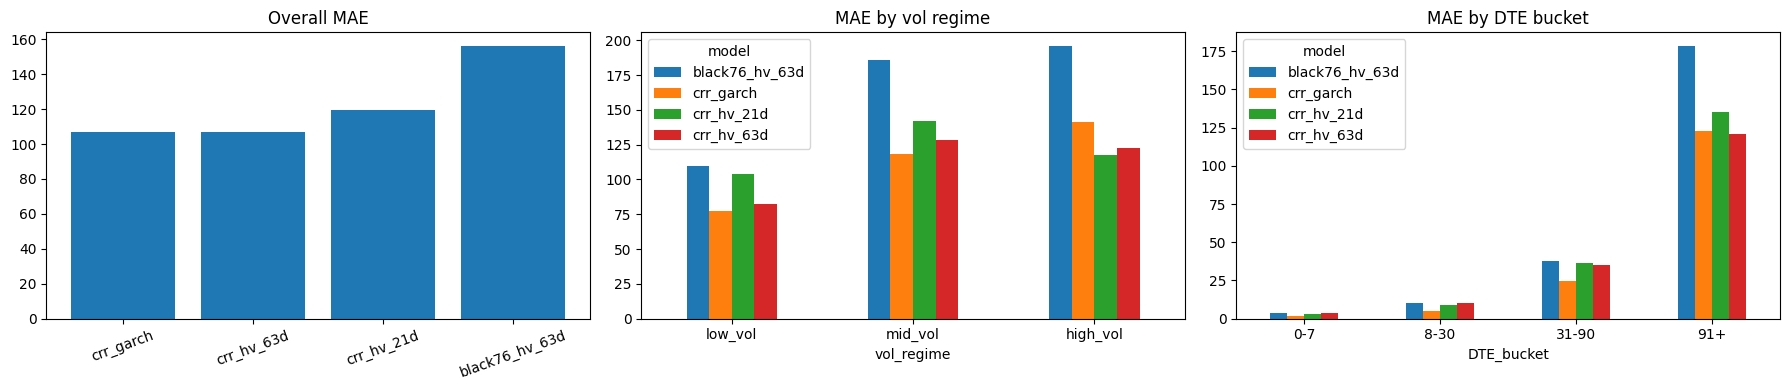

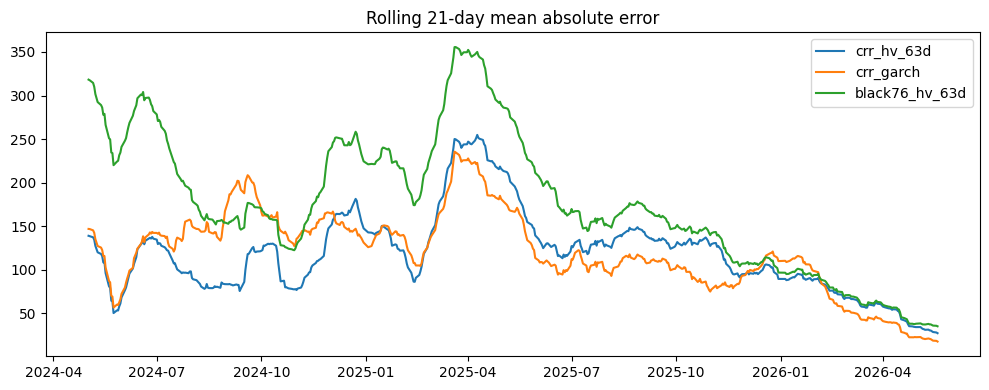

In [13]:
compare_models = ['crr_hv_21d', 'crr_hv_63d', 'crr_garch', 'black76_hv_63d']
pricing_df['moneyness_bucket'] = pd.cut(
    pricing_df['moneyness'],
    bins=[0, 0.9, 0.97, 1.03, 1.1, np.inf],
    labels=['deep_OTM', 'OTM', 'ATM', 'ITM', 'deep_ITM'],
)
pricing_df['DTE_bucket'] = pd.cut(
    pricing_df['DTE_DAYS'],
    bins=[0, 7, 30, 90, np.inf],
    labels=['0-7', '8-30', '31-90', '91+'],
)
pricing_df['abs_log_moneyness'] = pricing_df['log_moneyness'].abs()

common_df = restrict_to_common_sample(pricing_df, compare_models)

overall_table = pd.DataFrame([
    {'model': model_name, **calc_metrics(common_df, model_name)}
    for model_name in compare_models
]).sort_values('MAE').reset_index(drop=True)
display(overall_table)

by_vol_tables = []
for model_name in compare_models:
    tmp = calc_metrics_by_group(common_df, model_name, 'vol_regime')
    tmp['model'] = model_name
    by_vol_tables.append(tmp)
by_vol_table = pd.concat(by_vol_tables, ignore_index=True)
display(by_vol_table)

by_dte_tables = []
for model_name in compare_models:
    tmp = calc_metrics_by_group(common_df, model_name, 'DTE_bucket')
    tmp['model'] = model_name
    by_dte_tables.append(tmp)
by_dte_table = pd.concat(by_dte_tables, ignore_index=True)
display(by_dte_table)

by_money_tables = []
for model_name in compare_models:
    tmp = calc_metrics_by_group(common_df, model_name, 'moneyness_bucket')
    tmp['model'] = model_name
    by_money_tables.append(tmp)
by_money_table = pd.concat(by_money_tables, ignore_index=True)
display(by_money_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(overall_table['model'], overall_table['MAE'])
axes[0].set_title('Overall MAE')
axes[0].tick_params(axis='x', rotation=20)

pivot_vol = by_vol_table.dropna(subset=['vol_regime']).pivot(index='vol_regime', columns='model', values='MAE')
pivot_vol.plot(kind='bar', ax=axes[1])
axes[1].set_title('MAE by vol regime')
axes[1].tick_params(axis='x', rotation=0)

pivot_dte = by_dte_table.dropna(subset=['DTE_bucket']).pivot(index='DTE_bucket', columns='model', values='MAE')
pivot_dte.plot(kind='bar', ax=axes[2])
axes[2].set_title('MAE by DTE bucket')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

rolling = (
    common_df.groupby('TRADEDATE')[[
        'abs_error_crr_hv_63d', 'abs_error_crr_garch', 'abs_error_black76_hv_63d'
    ]]
    .mean()
    .rolling(21)
    .mean()
    .reset_index()
)
plt.figure(figsize=(10, 4))
plt.plot(rolling['TRADEDATE'], rolling['abs_error_crr_hv_63d'], label='crr_hv_63d')
plt.plot(rolling['TRADEDATE'], rolling['abs_error_crr_garch'], label='crr_garch')
plt.plot(rolling['TRADEDATE'], rolling['abs_error_black76_hv_63d'], label='black76_hv_63d')
plt.title('Rolling 21-day mean absolute error')
plt.legend()
plt.tight_layout()
plt.show()


## 9a. TVNAE — нормированная ошибка по временно́й стоимости

Стандартные метрики (MAE, RMSE) измеряют абсолютное отклонение в пунктах. При выборке с преобладанием длинных deep-ITM опционов ошибка масштабируется с внутренней стоимостью контракта, а не с качеством волатильностной модели.

**TVNAE** (Time-Value Normalized Absolute Error) нормирует ошибку на временну́ю стоимость опциона:

$$\text{TVNAE}_i = \frac{|\hat{P}_i - P_i|}{TV_i}, \quad TV_i = P_i - H(F_i, K_i)$$

Временна́я стоимость — это именно та компонента цены, которую модель волатильности пытается объяснить. Порог $TV \geq 10$ пунктов исключает экстремально малые значения знаменателя.


In [ ]:

# ── TVNAE: Time-Value Normalized Absolute Error ──────────────────────────────
# Нормировка ошибки на временну́ю стоимость опциона (time value = market_price - intrinsic_value).
# Это позволяет сравнивать модели по качеству оценки именно опциональной компоненты,
# а не по абсолютному масштабу цены (который у deep-ITM контрактов огромен).

TV_THRESHOLD = 10.0  # минимальная временна́я стоимость для включения в расчёт

# Intrinsic value
common_df['intrinsic'] = np.where(
    common_df['option_type_norm'] == 'call',
    np.maximum(common_df['F'] - common_df['K'], 0.0),
    np.maximum(common_df['K'] - common_df['F'], 0.0),
)
common_df['time_value'] = common_df['market_price'] - common_df['intrinsic']

tv_df = common_df[common_df['time_value'] >= TV_THRESHOLD].copy()
print(f"TV >= {TV_THRESHOLD}: {len(tv_df)} obs ({len(tv_df)/len(common_df)*100:.1f}% of common sample)")

# --- Overall TVNAE ---
american_models = ['crr_hv_21d', 'crr_hv_63d', 'crr_garch']
tvnae_overall_rows = []
for m in american_models:
    abs_err = tv_df[f'error_{m}'].abs()
    signed_err = tv_df[f'error_{m}']
    tv = tv_df['time_value']
    tvnae_overall_rows.append({
        'model': m,
        'N': len(tv_df),
        'mean_TVNAE': round(float((abs_err / tv).mean()), 4),
        'median_TVNAE': round(float((abs_err / tv).median()), 4),
        'mean_signed_TVE': round(float((signed_err / tv).mean()), 4),
    })
tvnae_overall = pd.DataFrame(tvnae_overall_rows).sort_values('mean_TVNAE').reset_index(drop=True)
print("\n=== Overall TVNAE ===")
display(tvnae_overall)

# --- TVNAE by vol regime ---
tvnae_vol_rows = []
for m in american_models:
    for reg in ['low_vol', 'mid_vol', 'high_vol']:
        sub = tv_df[tv_df['vol_regime'] == reg]
        if sub.empty:
            continue
        tvnae = (sub[f'error_{m}'].abs() / sub['time_value']).mean()
        tvnae_vol_rows.append({'model': m, 'vol_regime': reg, 'N': len(sub), 'mean_TVNAE': round(float(tvnae), 4)})
tvnae_vol = pd.DataFrame(tvnae_vol_rows)
print("\n=== TVNAE by vol regime ===")
display(tvnae_vol.pivot(index='model', columns='vol_regime', values='mean_TVNAE'))

# --- TVNAE by DTE bucket ---
tvnae_dte_rows = []
for m in american_models:
    for dte in ['0-7', '8-30', '31-90', '91+']:
        sub = tv_df[tv_df['DTE_bucket'] == dte]
        if sub.empty:
            continue
        tvnae = (sub[f'error_{m}'].abs() / sub['time_value']).mean()
        tvnae_dte_rows.append({'model': m, 'DTE_bucket': dte, 'N': len(sub), 'mean_TVNAE': round(float(tvnae), 4)})
tvnae_dte = pd.DataFrame(tvnae_dte_rows)
print("\n=== TVNAE by DTE bucket ===")
display(tvnae_dte.pivot(index='model', columns='DTE_bucket', values='mean_TVNAE'))

# --- Save ---
tvnae_overall.to_csv(results_dir / 'tvnae_overall.csv', index=False)
tvnae_vol.to_csv(results_dir / 'tvnae_by_vol_regime.csv', index=False)
tvnae_dte.to_csv(results_dir / 'tvnae_by_dte_bucket.csv', index=False)
print("\nSaved TVNAE results to", results_dir)


## 10. Сохранение артефактов

Этот блок сохраняет готовый modelling sample и результаты моделей. Он оставлен как чистовой шаблон: перед запуском можно решить, хотите ли вы хранить intermediate datasets отдельно.


## 10. Descriptive OLS with clustered standard errors

Этот блок нужен только как **descriptive check**: он показывает, связаны ли `high_vol`, `DTE` и `abs_log_moneyness` с размером pricing error. Здесь мы уже не используем простые `HC3`, а кластеризуем стандартные ошибки по `TRADEDATE`, чтобы не игнорировать внутридневную зависимость между опционными наблюдениями. При этом выводы всё равно следует трактовать как описательные, а не как строгую причинную эконометрику.


In [14]:
ols_df = common_df[['TRADEDATE', 'abs_error_crr_hv_63d', 'vol_regime', 'DTE_DAYS', 'log_moneyness', 'option_type_norm']].dropna().copy()
ols_df['high_vol_dummy'] = (ols_df['vol_regime'] == 'high_vol').astype(int)
ols_df['abs_log_moneyness'] = ols_df['log_moneyness'].abs()
ols_df['trade_date_cluster'] = ols_df['TRADEDATE'].astype(str)

ols_model_1 = smf.ols('abs_error_crr_hv_63d ~ high_vol_dummy', data=ols_df).fit(
    cov_type='cluster', cov_kwds={'groups': ols_df['trade_date_cluster']}
)
ols_model_2 = smf.ols('abs_error_crr_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness', data=ols_df).fit(
    cov_type='cluster', cov_kwds={'groups': ols_df['trade_date_cluster']}
)
ols_model_3 = smf.ols('abs_error_crr_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness + C(option_type_norm)', data=ols_df).fit(
    cov_type='cluster', cov_kwds={'groups': ols_df['trade_date_cluster']}
)

print(ols_model_1.summary())
print(ols_model_2.summary())
print(ols_model_3.summary())


                             OLS Regression Results                             
Dep. Variable:     abs_error_crr_hv_63d   R-squared:                       0.011
Model:                              OLS   Adj. R-squared:                  0.011
Method:                   Least Squares   F-statistic:                     15.40
Date:                  Sun, 31 May 2026   Prob (F-statistic):           9.82e-05
Time:                          12:51:04   Log-Likelihood:            -1.0700e+05
No. Observations:                 18058   AIC:                         2.140e+05
Df Residuals:                     18056   BIC:                         2.140e+05
Df Model:                             1                                         
Covariance Type:                cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        101.382

## 11. Sensitivity check по безрисковой ставке

Ставка `r = 0.16` остаётся MVP-допущением, но теперь мы явно проверяем чувствительность лучших результатов к нескольким альтернативным значениям ставки. Это не заменяет полноценный временной ряд ставок, но даёт понять, насколько ranking моделей может зависеть от выбранного `r`.


In [15]:
def price_with_alt_rate(frame: pd.DataFrame, sigma_col: str, rate_value: float, steps: int = 100) -> pd.DataFrame:
    sub = frame.copy()
    valid_mask = (
        (sub['market_price'] > 0)
        & (sub['F'] > 0)
        & (sub['K'] > 0)
        & (sub['T'] > 0)
        & (sub[sigma_col] > 0)
        & sub['option_type_norm'].isin(['call', 'put'])
    )
    prices = pd.Series(np.nan, index=sub.index)
    prices.loc[valid_mask] = sub.loc[valid_mask].apply(
        lambda row: american_futures_option_crr(
            F=float(row['F']),
            K=float(row['K']),
            T=float(row['T']),
            r=rate_value,
            sigma=float(row[sigma_col]),
            option_type=str(row['option_type_norm']),
            steps=steps,
        ),
        axis=1,
    )
    out = pd.DataFrame({'model_price': prices})
    out['error'] = out['model_price'] - sub['market_price']
    out['abs_error'] = out['error'].abs()
    out['sq_error'] = out['error'] ** 2
    out['pct_error'] = out['error'] / sub['market_price']
    return out

rate_rows = []
rate_grid = [0.12, 0.16, 0.20]
base_sample = common_df.copy()
for rate_value in rate_grid:
    tmp = price_with_alt_rate(base_sample, sigma_col='hv_63d', rate_value=rate_value, steps=100)
    valid = tmp['model_price'].notna()
    rate_rows.append({
        'r': rate_value,
        'N': int(valid.sum()),
        'MAE': float(tmp.loc[valid, 'abs_error'].mean()),
        'RMSE': float(np.sqrt(tmp.loc[valid, 'sq_error'].mean())),
        'mean_error': float(tmp.loc[valid, 'error'].mean()),
        'median_abs_error': float(tmp.loc[valid, 'abs_error'].median()),
        'mean_abs_pct_error': float(tmp.loc[valid, 'pct_error'].abs().mean()),
    })
rate_sensitivity = pd.DataFrame(rate_rows).sort_values('MAE').reset_index(drop=True)
rate_sensitivity


,r,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,0.12,18058,104.574680,137.528192,-81.956780,82.325728,3.928562
1,0.16,18058,107.148768,140.632495,-89.724781,84.451612,3.765533
2,0.20,18058,109.835672,144.060630,-96.304881,86.889049,3.615938


## 12. Сохранение артефактов

Ниже сохраняются итоговые таблицы и результаты clean-model pipeline. Дополнительно сохраняется таблица sensitivity по ставке, чтобы потом не пересчитывать её отдельно.


In [16]:
modelling_sample_path = results_dir / 'modelling_sample_mxi_clean.parquet'
pricing_results_path = results_dir / 'pricing_results_mxi_clean.parquet'
overall_metrics_path = results_dir / 'model_comparison_overall.csv'
by_vol_path = results_dir / 'model_comparison_by_vol_regime.csv'
by_dte_path = results_dir / 'model_comparison_by_dte_bucket.csv'
by_money_path = results_dir / 'model_comparison_by_moneyness_bucket.csv'
rate_sensitivity_path = results_dir / 'rate_sensitivity_crr_hv_63d.csv'

modelling_df.to_parquet(modelling_sample_path, index=False)
pricing_df.to_parquet(pricing_results_path, index=False)
overall_table.to_csv(overall_metrics_path, index=False)
by_vol_table.to_csv(by_vol_path, index=False)
by_dte_table.to_csv(by_dte_path, index=False)
by_money_table.to_csv(by_money_path, index=False)
rate_sensitivity.to_csv(rate_sensitivity_path, index=False)

print('Saved modelling sample to', modelling_sample_path)
print('Saved pricing results to', pricing_results_path)
print('Saved metrics to', results_dir)
print('Saved rate sensitivity to', rate_sensitivity_path)


Saved modelling sample to /Users/maria/Desktop/Code/HSE/COURSEBOOK/clear/results_models/modelling_sample_mxi_clean.parquet
Saved pricing results to /Users/maria/Desktop/Code/HSE/COURSEBOOK/clear/results_models/pricing_results_mxi_clean.parquet
Saved metrics to /Users/maria/Desktop/Code/HSE/COURSEBOOK/clear/results_models
Saved rate sensitivity to /Users/maria/Desktop/Code/HSE/COURSEBOOK/clear/results_models/rate_sensitivity_crr_hv_63d.csv


## 11. Что дальше

После запуска этого notebook логичный порядок такой:
1. построить `pricing_df` для `crr_hv_21d`, `crr_hv_63d`, `crr_garch`;
2. сравнить модели на `common_df`;
3. только после этого переходить к отдельной эконометрике ошибок и robustness checks.

Главное отличие от старых черновиков: теперь модельная часть опирается на **правильный futures underlying** и избегает самых сильных методологических ошибок.
